# **Raporti — LAB11:**
## **Lënda:** Hyrje në Laborator
## **Kodi i laboratorit:** LAB11
## **Titulli:** Saktësia e GPS/GNSS dhe Variacioni i Pozicionit
## **Studentja:** Albana Hoxha
## **Grupi:** 1
## **Data e zhvillimit të laboratorit:** 20-05-2026
## **Data e dorëzimit:** 03-06-2026
## **Pedagogu:** Ervin Kafexhiu

## **1. Qëllimi**

Qëllimi i këtij laboratori është të studiohet se si ndryshon pozicioni i matur nga një smartphone edhe kur telefoni qëndron i palëvizur. Studentët do të regjistrojnë të dhëna GPS/GNSS në kohë, do të analizojnë shpërndarjen e koordinatave dhe do të vlerësojnë saktësinë praktike të matjes së pozicionit.

Në këtë laborator, pozicioni nuk trajtohet si një numër i vetëm “i saktë”, por si një madhësi eksperimentale me variacion, devijim dhe pasiguri.

## **2. Teoria**
GPS është pjesë e familjes më të gjerë GNSS — Global Navigation Satellite Systems. GNSS përfshin sisteme si GPS (Amerikan), Galileo (Europian), GLONASS (Rus) dhe BeiDou (Kinez), të cilat transmetojnë sinjale nga satelitët drejt marrësve në Tokë. Marrësi përdor kohën e mbërritjes së sinjaleve për të llogaritur largësinë nga disa satelitë dhe, prej tyre, pozicionin. Për përcaktimin e pozicionit dhe kohës nevojiten zakonisht sinjale nga të paktën katër satelitë. (GPS.gov)

Saktësia e pozicionit nuk është konstante. Sipas GPS.gov, telefonat inteligjentë me GPS janë zakonisht të saktë brenda një rrezeje rreth 4.9 m në qiell të hapur, por saktësia përkeqësohet pranë ndërtesave, urave, pemëve dhe pengesave të tjera. Faktorë të rëndësishëm janë gjeometria e satelitëve, bllokimi i sinjalit, atmosfera dhe cilësia e marrësit. (GPS.gov)

Në këtë laborator nuk kërkohet të arrihet saktësi gjeodezike. Qëllimi është të studiohet sjellja statistikore e matjeve të pozicionit me pajisje të zakonshme.

## **3. Aparatura / Software**

Për realizimin e laboratorit u përdorën:

* Telefon inteligjent me GPS/GNSS.
* Laptop me Python/Jupyter.
* Akses në një hapësirë të hapur jashtë ndërtesës.
* phyphox — Lexon sensorët e telefonit dhe eksporton të dhënat për analizë. Eksperimenti “Location (GPS)” jep të dhëna nga sensori GPS/lokacionit të telefonit.

## **4. Procedura**

Eksperimenti u organizua në tre pjesë kryesore, me qëllim që të analizohej sjellja e saktësisë GPS/GNSS në kushte të ndryshme mjedisore dhe dinamike.

### Eksperimenti A — Qiell i hapur (telefon i palëvizur)

Në këtë pjesë, telefoni u vendos në një pozicion fiks në një hapësirë të hapur, larg ndërtesave të larta, pemëve dhe pengesave të tjera që mund të ndikojnë në sinjalin GPS. Qëllimi ishte të studiohej variacioni natyral i matjes kur pajisja nuk lëviz.

- U krye regjistrim i vazhdueshëm për një periudhë 5–10 minutash
- Intervali i marrjes së të dhënave ishte afërsisht 1 sekondë
- Telefoni u mbajt plotësisht i palëvizur gjatë gjithë matjes për të shmangur ndikime mekanike




### ***gps_outdoor_stationary.csv***

### Eksperimenti B — Pranë ndërtesës (kushte me pengesa sinjali)

Në këtë fazë, matjet u përsëritën në një ambient ku sinjali GPS është më i kufizuar, si pranë ndërtesave të larta, mureve ose strukturave që mund të shkaktojnë reflektim ose bllokim të sinjalit satelitor.

- Regjistrimi u krye për 5–10 minuta, në të njëjtin interval kohe si në Eksperimentin A
- Telefoni u vendos përsëri në një pozicion të palëvizur
- U ruajt i njëjti format i të dhënave për të lehtësuar krahasimin



###  ***gps_indoor.csv***

### Eksperimenti C — Lëvizje e kontrolluar

Në këtë pjesë u analizua sjellja e GPS gjatë lëvizjes reale, duke krijuar një trajektore të thjeshtë dhe të kontrolluar.

- U zgjodh një rrugë e shkurtër prej afërsisht 30–50 metrash
- Telefoni filloi regjistrimin përpara nisjes së ecjes
- U ec me shpejtësi të ngadaltë dhe sa më konstante përgjatë një vije të drejtë
- Regjistrimi u ndal në fund të segmentit të lëvizjes



### ***gps_walk.csv***

## 5. Mbledhja e të Dhënave

Të dhënat përfshijnë:
- Kohën
- Latitude
- Longitude
- Altitude 
- Saktësia (Accuracy)
- Numri i satelitëve 

Të dhënat u eksportuan në format CSV.

## **5. Analiza e të dhënave**


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/gps_outdoor_stationary.csv")

lat_col = "Latitude (°)"
lon_col = "Longitude (°)"
time_col = "Time (s)"

lat = pd.to_numeric(df[lat_col], errors="coerce")
lon = pd.to_numeric(df[lon_col], errors="coerce")

mask = ~(lat.isna() | lon.isna())

lat = lat[mask].to_numpy()
lon = lon[mask].to_numpy()

print("Numri i matjeve:", len(lat))
print("Latitude mesatare:", np.mean(lat))
print("Longitude mesatare:", np.mean(lon))

Numri i matjeve: 605
Latitude mesatare: 41.338975640413224
Longitude mesatare: 19.822788203371903


## Konvertimi i koordinatave në metra

In [33]:
R = 6371000

lat_rad = np.deg2rad(lat)
lon_rad = np.deg2rad(lon)

lat0 = np.mean(lat_rad)
lon0 = np.mean(lon_rad)

x = R * np.cos(lat0) * (lon_rad - lon0)
y = R * (lat_rad - lat0)

r = np.sqrt(x**2 + y**2)

print("Devijimi standard ne x [m]:", np.std(x, ddof=1))
print("Devijimi standard ne y [m]:", np.std(y, ddof=1))
print("Devijimi radial mesatar [m]:", np.mean(r))
print("Devijimi radial maksimal [m]:", np.max(r))
print("68% e pikave brenda [m]:", np.percentile(r, 68))
print("95% e pikave brenda [m]:", np.percentile(r, 95))

Devijimi standard ne x [m]: 2.7216608055453304
Devijimi standard ne y [m]: 2.354147719187377
Devijimi radial mesatar [m]: 2.9411605345652863
Devijimi radial maksimal [m]: 14.641688474867873
68% e pikave brenda [m]: 3.5683077607435103
95% e pikave brenda [m]: 6.5428342097449415


## 6. Grafikët kryesorë
### 6.1 Shpërndarja 2D e pozicioneve

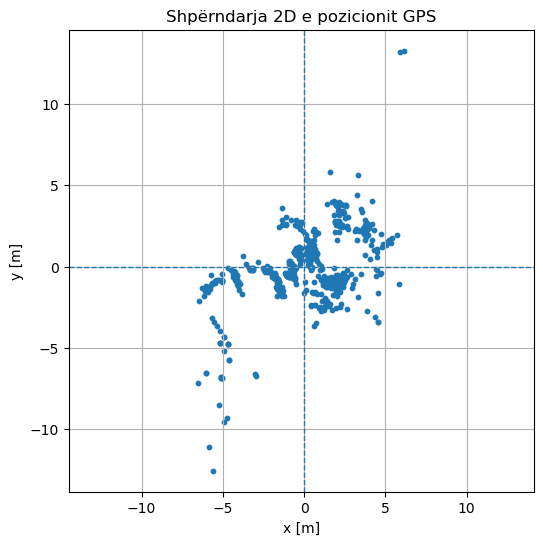

In [34]:
plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=10)
plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Shpërndarja 2D e pozicionit GPS")
plt.axis("equal")
plt.grid(True)
plt.show()

Ky grafik tregon “renë” e pikave të matura rreth pozicionit mesatar. Nëse telefoni ishte i palëvizur, përhapja e pikave përfaqëson variacionin e matjes.

### 6.2 Histogrami i devijimit radial

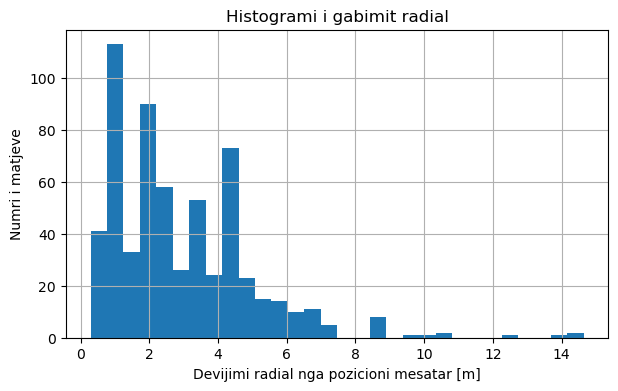

In [35]:
plt.figure(figsize=(7, 4))
plt.hist(r, bins=30)
plt.xlabel("Devijimi radial nga pozicioni mesatar [m]")
plt.ylabel("Numri i matjeve")
plt.title("Histogrami i gabimit radial")
plt.grid(True)
plt.show()

Kjo histogram tregon sa shpesh pozicioni i matur bie brenda një distance të caktuar nga pozicioni mesatar.

### 6.3 Pozicioni në funksion të kohës

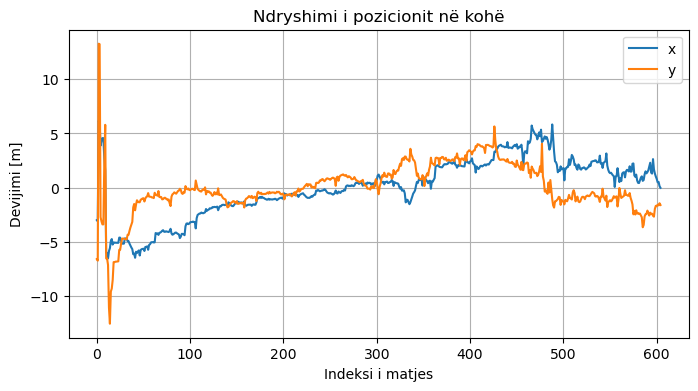

In [36]:
plt.figure(figsize=(8, 4))
plt.plot(x, label="x")
plt.plot(y, label="y")
plt.xlabel("Indeksi i matjes")
plt.ylabel("Devijimi [m]")
plt.title("Ndryshimi i pozicionit në kohë")
plt.legend()
plt.grid(True)
plt.show()

Ky grafik tregon nëse pozicioni ka drift gradual, kërcime të papritura ose luhatje rreth mesatares.

### 6.4 Krahasimi i dy kushteve

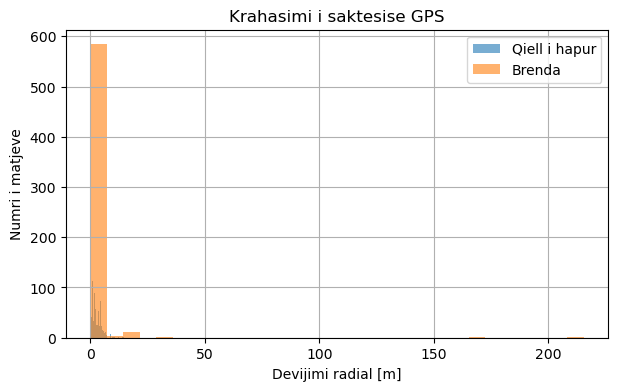

In [37]:
def load_gps_csv(filename):
    df = pd.read_csv(filename)

    lat = pd.to_numeric(df["Latitude (°)"], errors="coerce")
    lon = pd.to_numeric(df["Longitude (°)"], errors="coerce")

    mask = ~(lat.isna() | lon.isna())

    lat = lat[mask].to_numpy()
    lon = lon[mask].to_numpy()

    R = 6371000

    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)

    lat0 = np.mean(lat_rad)
    lon0 = np.mean(lon_rad)

    x = R * np.cos(lat0) * (lon_rad - lon0)
    y = R * (lat_rad - lat0)

    r = np.sqrt(x**2 + y**2)

    return r

r1 = load_gps_csv("data/gps_outdoor_stationary.csv")
r2 = load_gps_csv("data/gps_indoor.csv")

plt.figure(figsize=(7,4))

plt.hist(r1, bins=30, alpha=0.6, label="Qiell i hapur")
plt.hist(r2, bins=30, alpha=0.6, label="Brenda")

plt.xlabel("Devijimi radial [m]")
plt.ylabel("Numri i matjeve")
plt.title("Krahasimi i saktesise GPS")

plt.legend()
plt.grid(True)
plt.show()

## 7.Përshkrimi i eksperimentit

* Ku u krye matja?
Matjet u realizuan në nje hapësirë publike dhe brena një ndërtese.

* Çfarë telefoni u përdor?
Për regjistrimin e të dhënave u përdor një telefon inteligjent *iPhone*.

* Çfarë aplikacioni u përdor?
Si aplikacion për mbledhjen e të dhënave GPS u përdor **phyphox**.

* Sa zgjati matja?
Matja zgjati rreth  5–10 minuta për secilin eksperiment.

* Cili ishte intervali i regjistrimit?
Intervali i regjistrimit ishte  afërsisht  1 sekondë midis pikave të njëpasnjëshme.

* A ishte telefoni i palëvizur apo në lëvizje?
Gjatë Eksperimentit A, telefoni ishte i palëvizur, i vendosur në një pozicion fiks për të minimizuar lëvizjet dhe gabimet e matjes.
Në Eksperimentin B, matjet u kryen pranë ndërtesave, ku kishte pengesa të mundshme për sinjalin GPS.

* A kishte ndërtesa, pemë ose pengesa pranë?
Mjedisi përreth përfshinte pallate, pemë, rrugë urbane.


## 8.Diskutim

Kur telefoni qëndron i palëvizur, pozicioni i GPS nuk mbetet fiks. Edhe pse telefoni nuk lëviz, koordinatat ndryshojnë pak nga një matje në tjetrën për shkak të gabimeve të sinjalit.

Pikat e matjes zakonisht shpërndahen rreth një zone të vogël. Kjo përhapje është zakonisht disa metra dhe tregon saktësinë reale të GPS-it në telefon.

Rezultatet janë në përgjithësi në përputhje me saktësinë e pritshme të GPS në telefon, e cila zakonisht është rreth disa metrash në kushte të mira.

Kur matjet bëhen pranë ndërtesave, gabimet rriten. Ndërtesat bllokojnë ose reflektojnë sinjalin GPS, prandaj pikat shpërndahen më shumë dhe bëhen më pak të sakta.

Me kalimin e kohës mund të vërehet një ndryshim i lehtë i pozicionit (drift), edhe pse telefoni nuk lëviz.

Gjithashtu mund të ketë disa pika që janë shumë larg nga të tjerat. Këto quhen gabime dhe ndodhin për shkak të humbjes së sinjalit ose ndërhyrjeve.

Për këtë arsye, një matje e vetme GPS nuk është plotësisht e saktë. Për një rezultat më të mirë duhet të merren shumë matje dhe të përdoret mesatarja e tyre.

## 9. Përfundime

### Përgjigjet e pyetjeve për analizë

1. Pse duhen të paktën katër satelitë për të përcaktuar pozicionin dhe kohën?
* Sepse marrësi GPS duhet të zgjidhë katër të panjohura: gjerësinë, gjatësinë, lartësinë dhe gabimin e orës së pajisjes. Çdo satelit jep një ekuacion, prandaj duhen të paktën katër satelitë për një zgjidhje të plotë.

2. Pse pozicioni ndryshon edhe kur telefoni është i palëvizur?
* Sepse sinjali GPS ka gabime të vogla nga atmosfera, reflektimi i sinjalit dhe kufizimet e telefonit. Këto bëjnë që matjet të mos jenë identike çdo herë.

3. Cili është ndryshimi midis saktësisë dhe precizionit në këtë eksperiment?
* Saktësia tregon sa afër është mesatarja e matjeve me pozicionin real.
* Precizioni tregon sa afër janë matjet me njëra-tjetrën.
* Mund të kemi matje shumë të përqendruara (precize), por jo të sakta.

4. Pse sinjali GPS përkeqësohet pranë ndërtesave?
* Ndërtesat bllokojnë ose reflektojnë sinjalin satelitor. Kjo krijon gabime (multipath effect) dhe rrit pasigurinë e matjes.

5. Çfarë kuptimi ka $r_{95}$?
* $r_{95}$ është rrezja brenda së cilës ndodhen 95% e matjeve. Pra tregon sa e madhe është zona e gabimit të pozicionit në shumicën e rasteve.

6. A është mesatarja e pozicioneve gjithmonë pozicioni “i vërtetë”? Pse?
* Jo gjithmonë. Mesatarja redukton gabimet e rastësishme, por mund të mbetet e ndikuar nga gabime sistematike (p.sh. ndërtesa, drift ose sinjal i dobët).

7. Çfarë do të ndryshonte nëse do të përdornim një marrës GNSS profesional me RTK?
* Saktësia do të rritej shumë. Me RTK gabimi mund të ulet nga disa metra në disa centimetra, sepse përdoren korrigjime në kohë reale nga një stacion referencë.